In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from unet import Unet_sigmoid

In [11]:
from collections import OrderedDict

In [12]:
import unet_ein as ue
import pytorch_ssim

# Data

In [13]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [14]:
path = '/fuz attack/complete/'

In [15]:
trn_ , val_  = split(f'../dataset/{path}/normal/bin/',prc = 0.2, dataset_pct=  0.1, dim =(112,112), word_type=torch.float)
atk , _ = split(f'../dataset/{path}/attack/bin/',prc = 0 , dataset_pct=  0.1, dim = (112,112), word_type=torch.float)
dis , _ = split(f'../dataset/{path}/disable/bin/',prc = 0 , dataset_pct=  0.1, dim = (112,112), word_type=torch.float)
end , _ = split(f'../dataset/{path}/end/bin/',prc = 0 , dataset_pct=  0.1, dim = (112,112), word_type=torch.float)

In [16]:
bs = 8
seq_len = 20
overlap=0

In [17]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
#test_dl = Sequence_dl( test_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
dl =CombineDataLoader(trn_dl,v4_val_dl)

In [18]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])
v4_rec_dl = Sequence_dl( dis, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])
end_dl = Sequence_dl( end, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

# Custom Loss

Example of a custom loss

In [19]:
class binary:
    def __call__(self,ip,tgt):
        bs = tgt.size(0)
        seq_len = tgt.size(1)
        #ip is what comes out of the model
        
        ip = ip.view(bs,seq_len,-1).contiguous()[:,:,120:500] #customized setup
        tgt = tgt.view(bs,seq_len,-1).contiguous()[:,:,120:500] #customized setup
        
        loss = nn.functional.binary_cross_entropy(ip,tgt)
        return loss # returned loss

In [20]:
loss = binary() # Loss in an object

# Model

Example for model that its script in the document

In [22]:
class Unet_sigmoid(BaseModel):
    def __init__(self,att = False,name = 'U-net_sigmoid',pre=False):
        super().__init__(name)
        self.loss = []
        self.one = []
        ##Load pre-trained
        if att:
                self.unet = UNet_with_att(in_channels=1)#.cuda()
        else:
                self.unet = UNet(in_channels=1)#.cuda()
                print(pre)
                if pre:
                    state_dict = torch.load('unet/brain-segmentation-pytorch-master/weights/unet.pt', map_location="cuda:0")
                    self.unet.load_state_dict(state_dict)
    def forward(self,inputs):
        inputs = inputs.type(next(iter(self.parameters())).type())[:,None,:,:]
        #k = torch.cat([inputs,inputs,inputs],dim = 1)
        k = self.unet(inputs)
        return torch.sigmoid(k)

    def encode(self,inputs):
        inputs = inputs.type(next(iter(self.parameters())).type())[:,None,:,:]
        #k = torch.cat([inputs,inputs,inputs],dim = 1)
        k = self.unet.encode(inputs)
        return k
    def decode(self,*decoded_ips):
        k = self.unet.decode(*decoded_ips)
        return torch.sigmoid(k[:,0,:,:])
    
    
    def record(self,record):
        self.loss.append(record)
        
    def one_to_one(self,record):
        self.one.append(record)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, init_features=32):
        super(UNet, self).__init__()

        features = init_features
        self.encoder1 = UNet._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder2 = UNet._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder3 = UNet._block(features * 2, features * 4, name="enc3")
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder4 = UNet._block(features * 4, features * 8, name="enc4")
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = UNet._block(features * 8, features * 16, name="bottleneck")

        self.upconv4 = nn.ConvTranspose2d(
            features * 16, features * 8, kernel_size=2, stride=2
        )
        self.decoder4 = UNet._block((features * 8) * 2, features * 8, name="dec4")
        self.upconv3 = nn.ConvTranspose2d(
            features * 8, features * 4, kernel_size=2, stride=2
        )
        self.decoder3 = UNet._block((features * 4) * 2, features * 4, name="dec3")
        self.upconv2 = nn.ConvTranspose2d(
            features * 4, features * 2, kernel_size=2, stride=2
        )
        self.decoder2 = UNet._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose2d(
            features * 2, features, kernel_size=2, stride=2
        )
        self.decoder1 = UNet._block(features * 2, features, name="dec1")

        self.conv = nn.Conv2d(
            in_channels=features, out_channels=out_channels, kernel_size=1
        )
        

    def encode(self,x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))
        bottleneck = self.bottleneck(self.pool4(enc4))

        return [enc1,enc2,enc3,enc4,bottleneck]
    
    def decode(self,enc1,enc2,enc3,enc4,bottleneck):
        
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)


        dec3 = torch.cat((dec3, dec3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)

        dec2 = torch.cat((dec2, dec2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)

        dec1 = torch.cat((dec1, dec1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.conv(dec1)
    
    @staticmethod
    def _block(in_channels, features, name):
        return nn.Sequential(
            OrderedDict(
                [
                    (
                        name + "conv1",
                        nn.Conv2d(
                            in_channels=in_channels,
                            out_channels=features,
                            kernel_size=3,
                            padding=1,
                            bias=False,
                        ),
                    ),
                    (name + "norm1", nn.BatchNorm2d(num_features=features)),
                    (name + "relu1", nn.ReLU(inplace=True)),
                    (
                        name + "conv2",
                        nn.Conv2d(
                            in_channels=features,
                            out_channels=features,
                            kernel_size=3,
                            padding=1,
                            bias=False,
                        ),
                    ),
                    (name + "norm2", nn.BatchNorm2d(num_features=features)),
                    (name + "relu2", nn.ReLU(inplace=True)),
                ]
            )
        )



In [23]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len,d_model = 512,pre=True,n_layers=2,out_ch=512,dropout = 0.1):
        super().__init__()
        
        self.par = nn.Parameter(torch.rand(out_ch,7,7))
        self.unet = Unet_sigmoid(pre=pre)
        self.decode = nn.ConvTranspose3d(1,seq_len,(1,1,1))
        self.relu = nn.PReLU()
        self.lin = nn.Linear(seq_len*64,1)
        self.new_old_lin = nn.Linear(2,1)
        self.last_lin = torch.zeros(bs,1,1,1).cuda()
        
        
        self.out_ch = out_ch
        self.compress = nn.Conv2d(512,out_ch , (1,1))
        self.reconstruct = nn.Conv2d(out_ch, 512 , (1,1))

    def forward(self,x):
        bs = x.size(0)
        ts = x.size(1)
        x = x.view(bs*ts,x.size(2),x.size(3))
        u = self.unet.encode(x)
        bottle_neck = u[-1]
        bottle_neck = self.compress(bottle_neck)
        bottle_neck = bottle_neck.view(bs,ts,self.out_ch,7,7)
        encode = self.relu(torch.einsum('bschw,chw->bchw',bottle_neck,self.par))
        
        decode = self.decode(encode.view(bs,1,self.out_ch,7,7)) 
        u[-1] = torch.relu(decode.view(bs*ts,self.out_ch,7,7)) 
        u[-1] = nn.functional.relu(self.reconstruct(u[-1]))
             
        img = self.unet.decode(*u)
        
        return img.view(bs,ts,img.size(2),img.size(2))


In [24]:
m =  unet_seq(bs,seq_len,pre=False,out_ch=512).cuda() # load the model and put it on gpu (cuda)

False


In [25]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [27]:
# Here we initialize our validation objects, each with a dataset
val2_item = Validate(v4_val_dl)
#test_item = Validate(test_dl)
v4_anml_item = Validate(v4_anml_dl)
v4_rec_item = Validate(v4_rec_dl)
end_item = Validate(end_dl)

In [28]:
learn.fit(m , opt , 2 , dl,loss) # notice we used the object loss

100%|██████████| 9/9 [00:02<00:00,  4.84it/s, loss : 0.5736323462592231]8] 

train Loss:  0.42117205262184143   validation loss:  0.5736323595046997
tensor(nan)


100%|██████████| 9/9 [00:01<00:00,  5.63it/s, loss : 0.17412669128841823]5]

train Loss:  0.21257081627845764   validation loss:  0.17412669956684113
tensor(nan)


In [30]:
#We use the validate object to evaluate the model on the dataset it carries
val2_item.evaluate(model = m , crit = loss)
#test_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit =  loss)
v4_rec_item.evaluate(model = m , crit =  loss)
end_item.evaluate(model = m , crit = loss)

  0%|          | 0/9 [00:00<?, ?it/s]

testing...


  0%|          | 0/6 [00:00<?, ?it/s].59it/s]

testing...


  0%|          | 0/31 [00:00<?, ?it/s]23it/s]

testing...


  0%|          | 0/211 [00:00<?, ?it/s].76it/s]

testing...


100%|██████████| 211/211 [00:37<00:00,  5.74it/s]

In [31]:
#We extract the results
a = torch.tensor(val2_item.test_loss)#.median()
#t = torch.tensor(test_item.test_loss)#.median()
b = torch.tensor(v4_anml_item.test_loss)#.median()
c = torch.tensor(v4_rec_item.test_loss)#.median()
d = torch.tensor(end_item.test_loss)#.median()

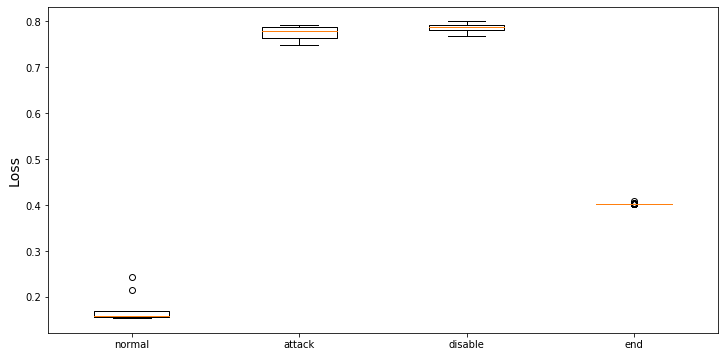

In [32]:
# visualize
fig,ax = plt.subplots(figsize=(12,6))
ax.boxplot([a,list(b),list(c),list(d)],showfliers = True);
ax.set_xticklabels(['normal','attack','disable','end']);
ax.set_ylabel('Loss',fontsize=14);

In [32]:
# save is different from save_all explained in the document , this saves the result and the script is written up there
#path = 'Models/documentation/fuz//unetand einsum conv3d/6/'
#save(path,[a,b])

In [33]:
# This will save the model and optimizer 
cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model

In [73]:
import unet

In [74]:
class adaptive_unet(BaseModel):
    def __init__(self):
        super().__init__()
        self.unet = unet.Unet_sigmoid()
    def forward(self,x):
        x = x.view(8*20,112,112)

        return self.unet(x)

In [75]:
m = adaptive_unet().cuda()

In [76]:
opt = torch.optim.Adam(m.parameters(),1e-3)
opt = BaseOptimizer(opt)
learn = learner()

In [77]:
# here we depend on 
cbs.load_all('documentation/fuz/unet/6/', model=m , opt=opt,learn=learn)

In [78]:
val2_item = Validate(v4_val_dl)
#test_item = Validate(test_dl)
v4_anml_item = Validate(v4_anml_dl)
v4_rec_item = Validate(v4_rec_dl)
end_item = Validate(end_dl)

In [110]:
learn.fit(m , opt , 2 , dl,torch.nn.functional.binary_cross_entropy  )

/mnt/5e85af0b-fa6b-4dca-a539-449bff7060b4/Work/logsagenttechnicaldepth/fit.py:51: UserWarning: Using a target size (torch.Size([1, 20, 112, 112])) that is different to the input size (torch.Size([20, 1, 112, 112])) is deprecated. Please ensure they have the same size.
  loss = crit(out,data)
  0%|          | 0/385 [00:00<?, ?it/s, Loss: 0]/s, loss : 4.507291021473749e-06] /mnt/5e85af0b-fa6b-4dca-a539-449bff7060b4/Work/logsagenttechnicaldepth/fit.py:81: UserWarning: Using a target size (torch.Size([1, 20, 112, 112])) that is different to the input size (torch.Size([20, 1, 112, 112])) is deprecated. Please ensure they have the same size.
  loss = crit(out,data)
100%|█████████▉| 384/385 [00:09<00:00, 40.02it/s, loss : 1.071698989107972e-06] 

train Loss:  4.507694484345848e-06   validation loss:  1.0716745464378619e-06
tensor(nan)


 99%|█████████▉| 383/385 [00:09<00:00, 40.40it/s, loss : 1.931130907658789e-07] ] 

train Loss:  7.277998292920529e-07   validation loss:  1.931253024167745e-07
tensor(nan)


In [79]:
%%time
val2_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy)

  0%|          | 0/92 [00:00<?, ?it/s]/mnt/5e85af0b-fa6b-4dca-a539-449bff7060b4/Work/logsagenttechnicaldepth/fit.py:145: UserWarning: Using a target size (torch.Size([8, 20, 112, 112])) that is different to the input size (torch.Size([160, 1, 112, 112])) is deprecated. Please ensure they have the same size.
  loss = crit(out,data)


testing...


100%|██████████| 92/92 [00:16<00:00,  5.72it/s]

CPU times: user 12.6 s, sys: 3.6 s, total: 16.2 s
Wall time: 16.5 s


In [112]:
#test_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy)
v4_anml_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy )
v4_rec_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy)
end_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy)

testing...


  0%|          | 4/2635 [00:00<01:10, 37.56it/s]]

testing...


  0%|          | 4/17731 [00:00<07:56, 37.24it/s]s]

testing...


100%|█████████▉| 17728/17731 [07:13<00:00, 38.84it/s]

In [113]:
a = torch.tensor(val2_item.test_loss)#.median()
#t = torch.tensor(test_item.test_loss)#.median()
b = torch.tensor(v4_anml_item.test_loss)#.median()
c = torch.tensor(v4_rec_item.test_loss)#.median()
d = torch.tensor(end_item.test_loss)#.median()

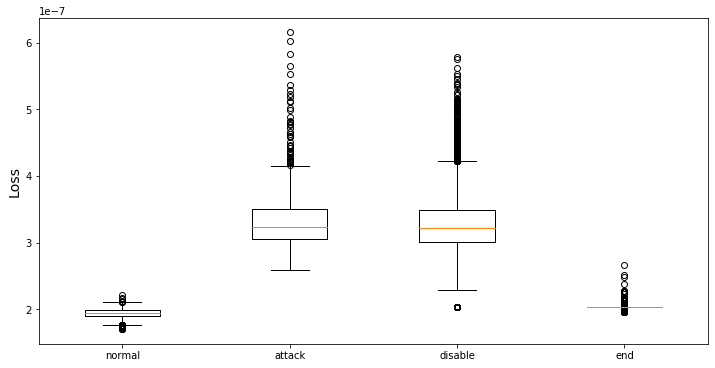

In [114]:
fig,ax = plt.subplots(figsize=(12,6))
ax.boxplot([a,list(b),list(c),list(d)],showfliers = True);
ax.set_xticklabels(['normal','attack','disable','end']);
ax.set_ylabel('Loss',fontsize=14);

In [90]:
path = 'Models/documentation/fuz/unet/6/'
#save(path,[a,b,c,d],names=['normal','attack','disable','end'])

In [91]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

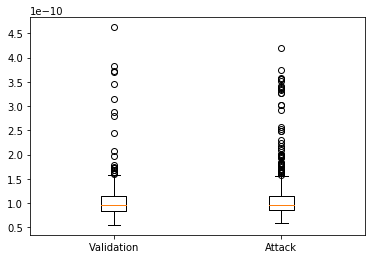

In [45]:
fig,ax = plt.subplots()
ax.boxplot([a,list(b)],showfliers = True);
ax.set_xticklabels(['Validation','Attack']);

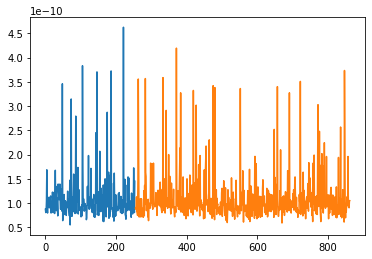

In [46]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

# Model with conv

In [34]:
class conv_enocder(BaseModel):    
    def __init__(self):
        super().__init__()

        self.encode = nn.Conv2d(seq_len,1,(1,1))
        self.decode = nn.ConvTranspose2d(1,seq_len,(1,1))
        self.relu = nn.PReLU()
        
    def forward(self,x):
        bs = x.size(0)
        ts = x.size(1)
        encode = self.encode(x)
        decode = self.decode(encode.view(bs,1,112,112)) 
        
        
             
        img = torch.sigmoid(decode)
        return img#torch.sigmoid(op)


In [35]:
m = conv_enocder().cuda()

In [36]:
opt = torch.optim.Adam(m.parameters(),1e-2)
opt = BaseOptimizer(opt)
learn = learner()

In [37]:
#cbs.load_all('documentation/fuz/conv/6/', model=m , opt=opt,learn=learn)

In [38]:
val2_item = Validate(v4_val_dl)
#test_item = Validate(test_dl)
v4_anml_item = Validate(v4_anml_dl)
v4_rec_item = Validate(v4_rec_dl)
end_item = Validate(end_dl)

In [39]:
learn.fit(m , opt , 2 , dl,loss)

 56%|█████▌    | 5/9 [00:00<00:00, 40.66it/s, loss : 0.5531522750854492]9]

train Loss:  0.6328347325325012   validation loss:  0.551103413105011
tensor(nan)


 22%|██▏       | 2/9 [00:00<00:00, 19.34it/s, loss : 0.4042937755584717]1] 

train Loss:  0.470792680978775   validation loss:  0.40073084831237793
tensor(nan)


In [40]:
%%time
val2_item.evaluate(model = m , crit = loss)

 11%|█         | 1/9 [00:00<00:00,  9.92it/s]

testing...
CPU times: user 42.8 ms, sys: 66.1 ms, total: 109 ms
Wall time: 299 ms


In [41]:
#test_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)
v4_rec_item.evaluate(model = m , crit = loss)
end_item.evaluate(model = m , crit = loss)

 83%|████████▎ | 5/6 [00:00<00:00, 41.55it/s]

testing...


 13%|█▎        | 4/31 [00:00<00:00, 39.76it/s]

testing...


  2%|▏         | 5/211 [00:00<00:04, 43.67it/s]

testing...


 99%|█████████▉| 209/211 [00:03<00:00, 67.53it/s]

In [42]:
a = torch.tensor(val2_item.test_loss)#.median()
#t = torch.tensor(test_item.test_loss)#.median()
b = torch.tensor(v4_anml_item.test_loss)#.median()
c = torch.tensor(v4_rec_item.test_loss)#.median()
d = torch.tensor(end_item.test_loss)#.median()

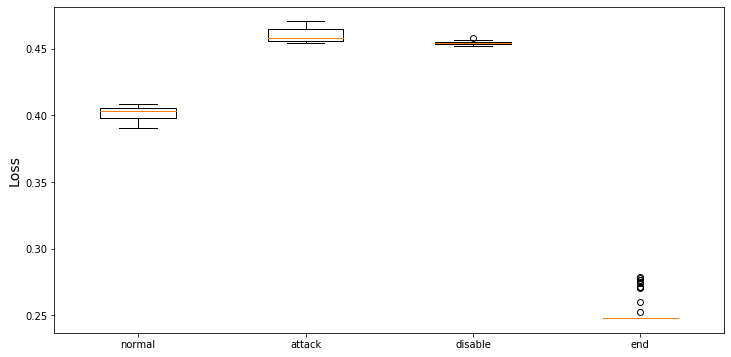

In [43]:
fig,ax = plt.subplots(figsize=(12,6))
ax.boxplot([a,list(b),list(c),list(d)],showfliers = True);
ax.set_xticklabels(['normal','attack','disable','end']);
ax.set_ylabel('Loss',fontsize=14);

In [59]:
path = 'Models/documentation/fuz/conv/ssim/6'
save(path,[a,b,c,d],names=['normal','attack','disable','end'])

In [60]:
cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model with Ein sum

In [61]:
class ein(BaseModel):    
    def __init__(self):
        super().__init__()
        
        self.par = nn.Parameter(torch.rand(112,112))
        self.decode = nn.ConvTranspose2d(1,seq_len,(1,1))
        self.relu = nn.PReLU()
                
    def forward(self,x):
        bs = x.size(0)
        ts = x.size(1)
        #x = x.view(bs*ts,x.size(2),x.size(3))
        
        
        encode = self.relu(torch.einsum('bshw,hw->bhw',x,self.par))
        decode = self.decode(encode.view(bs,1,112,112)) 
        
        
             
        img = torch.sigmoid(decode)
        return img


In [62]:
m = ein().cuda()

In [63]:
opt = torch.optim.Adam(m.parameters(),1e-2)
opt = BaseOptimizer(opt)
learn = learner()

In [64]:
#cbs.load_all('documentation/fuz/ein/6/', model=m , opt=opt,learn=learn)

In [65]:
val2_item = Validate(v4_val_dl)
#test_item = Validate(test_dl)
v4_anml_item = Validate(v4_anml_dl)
v4_rec_item = Validate(v4_rec_dl)
end_item = Validate(end_dl)

In [79]:
learn.fit(m , opt , 12 , dl,ssim_loss  )

100%|██████████| 92/92 [00:01<00:00, 48.80it/s, loss : 1.862678693688434] 2]

train Loss:  1.88120698928833   validation loss:  1.8626787662506104
tensor(nan)


 99%|█████████▉| 91/92 [00:01<00:00, 49.52it/s, loss : 1.7726457197587568]7]

train Loss:  1.843652367591858   validation loss:  1.772505760192871
tensor(nan)


 95%|█████████▍| 87/92 [00:01<00:00, 48.77it/s, loss : 1.6600499646417026]2]

...

train Loss:  1.5112154483795166   validation loss:  1.4810514450073242
tensor(nan)


 96%|█████████▌| 88/92 [00:02<00:00, 46.98it/s, loss : 1.4190378189086914]] 

train Loss:  1.4581074714660645   validation loss:  1.4162265062332153
tensor(nan)


 99%|█████████▉| 91/92 [00:02<00:00, 48.42it/s, loss : 1.3677058796306232]6]

train Loss:  1.406295657157898   validation loss:  1.3673937320709229
tensor(nan)


In [80]:
%%time
val2_item.evaluate(model = m , crit = ssim_loss)

  2%|▏         | 2/92 [00:00<00:04, 18.05it/s]

testing...


100%|██████████| 92/92 [00:01<00:00, 53.95it/s]

CPU times: user 1.27 s, sys: 446 ms, total: 1.72 s
Wall time: 1.9 s


In [81]:
#test_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy)
v4_anml_item.evaluate(model = m , crit = ssim_loss)
v4_rec_item.evaluate(model = m , crit = ssim_loss)
end_item.evaluate(model = m , crit = ssim_loss)

  5%|▌         | 3/60 [00:00<00:02, 27.77it/s]

testing...


  1%|          | 3/314 [00:00<00:12, 24.58it/s]

testing...


  0%|          | 3/2118 [00:00<01:17, 27.29it/s]]

testing...


100%|█████████▉| 2114/2118 [00:44<00:00, 44.87it/s]

In [82]:
a = torch.tensor(val2_item.test_loss)#.median()
#t = torch.tensor(test_item.test_loss)#.median()
b = torch.tensor(v4_anml_item.test_loss)#.median()
c = torch.tensor(v4_rec_item.test_loss)#.median()
d = torch.tensor(end_item.test_loss)#.median()

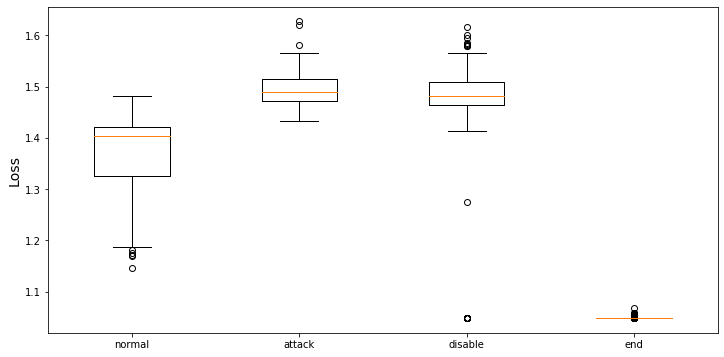

In [83]:
fig,ax = plt.subplots(figsize=(12,6))
ax.boxplot([a,list(b),list(c),list(d)],showfliers = True);
ax.set_xticklabels(['normal','attack','disable','end']);
ax.set_ylabel('Loss',fontsize=14);

In [72]:
path = 'Models/documentation/fuz/ein/ssim/6/'
save(path,[a,b,c,d],names=['normal','attack','disable','end'])

In [73]:
cbs.save_all(path,model=m,learn=learn,opt=opt)

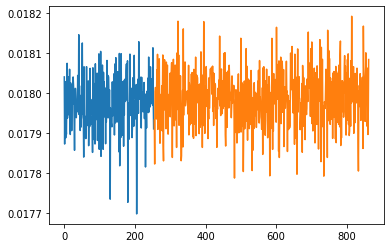

In [28]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

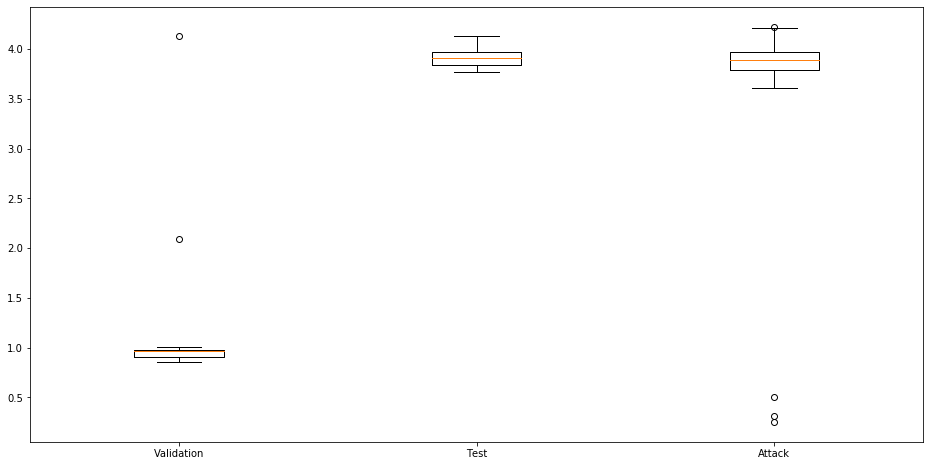

In [30]:
fig,ax = plt.subplots(figsize=(16,8))
ax.boxplot([a[:55],list(a[55:55+7]),list(a[55+7:55+7+39])],showfliers = True);
ax.set_xticklabels(['Validation','Test','Attack']);

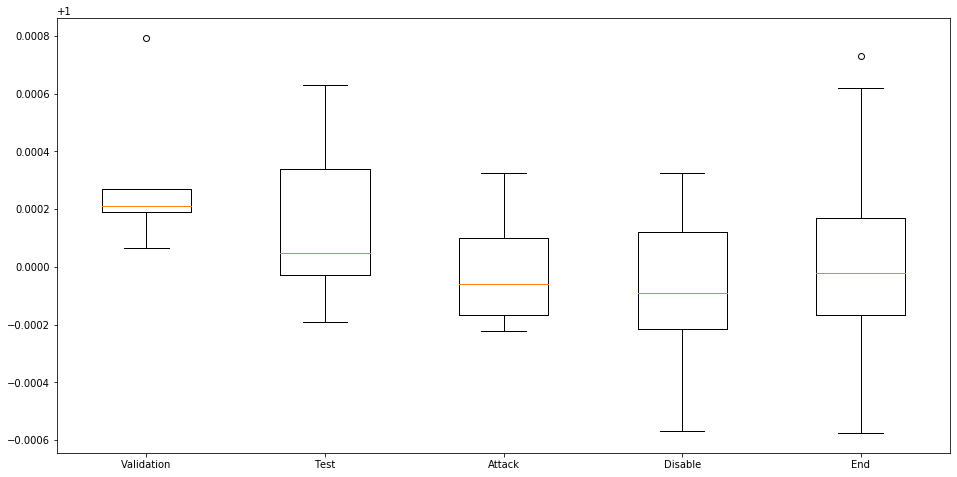

In [62]:
fig,ax = plt.subplots(figsize=(16,8))
ax.boxplot([a,list(t),list(b),list(c),list(d)],showfliers = True);
ax.set_xticklabels(['Validation','Test','Attack','Disable','End']);

# Model unet trans

In [19]:
class binary:
    def __call__(self,l,data):
        trans_ip = l[0]
        trans_op = l[1]
        recon_img = l[2]
        l1 = nn.functional.l1_loss(trans_ip,trans_op)
        binary = nn.functional.binary_cross_entropy(recon_img,data)
        return binary 

In [20]:
b = binary()

In [21]:
import modified_transformer.Models as m
import modified_transformer.SubLayers as sub
import torch
import numpy as np
import torch.nn as nn
from modified_transformer.Models import *
from modified_transformer.Layers import DecoderLayer
from up_down_sampler import *

In [22]:
import torch 
import torch.nn as nn

import ein as e
from basemodel import *
from collections import OrderedDict

In [23]:
m = ue.unet_ein(bs,seq_len,d_model=512,n_layers=2,dropout=0.1,pre=False).cuda()

In [24]:
opt = torch.optim.Adam(m.parameters(),1e-3)

In [25]:
opt = BaseOptimizer(opt)

In [26]:
learn = learner()

In [27]:
cbs.load_all('documentation/fuz/unet transformer/4/',model=m,opt=opt,learn=learn)

In [28]:
val2_item = Validate(v4_val_dl)

v4_anml_item = Validate(v4_anml_dl)
v4_rec_item = Validate(v4_rec_dl)
end_item = Validate(end_dl)

In [29]:
learn.fit(m , opt , 2 , dl,b  )

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Using a target size (torch.Size([8, 20, 112, 112])) that is different to the input size (torch.Size([160, 112, 112])) is deprecated. Please ensure they have the same size.
  import sys
100%|██████████| 92/92 [00:17<00:00,  5.42it/s, loss : 0.0015936327045378478]2]

train Loss:  0.0013992966851219535   validation loss:  0.0015936327399685979
tensor(nan)


100%|██████████| 92/92 [00:16<00:00,  5.46it/s, loss : 0.0011873400729635487]1]

train Loss:  0.0008901164983399212   validation loss:  0.001187340123578906
tensor(nan)


In [30]:
%%time
val2_item.evaluate(model = m , crit = b)

  0%|          | 0/92 [00:00<?, ?it/s]

testing...


/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Using a target size (torch.Size([8, 20, 112, 112])) that is different to the input size (torch.Size([160, 112, 112])) is deprecated. Please ensure they have the same size.
  import sys
100%|██████████| 92/92 [00:16<00:00,  5.47it/s]

CPU times: user 13.2 s, sys: 3.82 s, total: 17 s
Wall time: 17.2 s


In [31]:
#test_item.evaluate(model = m , crit = nn.functional.binary_cross_entropy)
v4_anml_item.evaluate(model = m , crit = b)
v4_rec_item.evaluate(model = m , crit = b)
end_item.evaluate(model = m , crit = b)

  0%|          | 0/60 [00:00<?, ?it/s]

testing...


/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Using a target size (torch.Size([8, 20, 112, 112])) that is different to the input size (torch.Size([160, 112, 112])) is deprecated. Please ensure they have the same size.
  import sys
  0%|          | 0/314 [00:00<?, ?it/s].44it/s]

testing...


  0%|          | 0/2118 [00:00<?, ?it/s]5.47it/s]

testing...


100%|██████████| 2118/2118 [06:28<00:00,  5.48it/s]

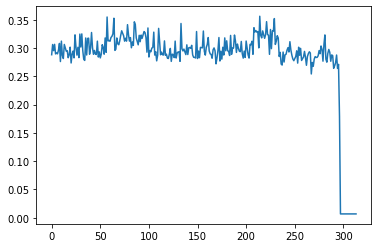

In [39]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))


In [32]:
a = torch.tensor(val2_item.test_loss)#.median()
#t = torch.tensor(test_item.test_loss)#.median()
b = torch.tensor(v4_anml_item.test_loss)#.median()
c = torch.tensor(v4_rec_item.test_loss)#.median()
d = torch.tensor(end_item.test_loss)#.median()

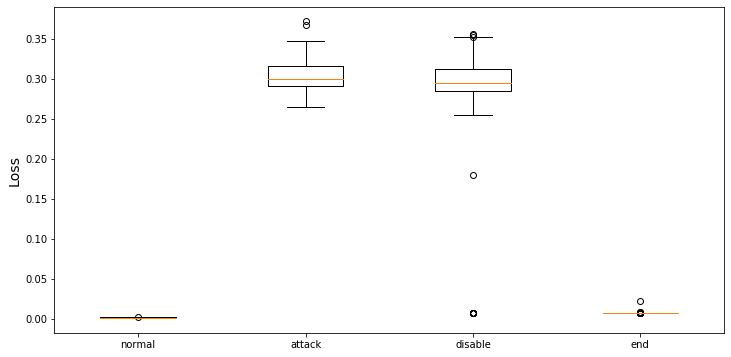

In [33]:
fig,ax = plt.subplots(figsize=(12,6))
ax.boxplot([a,list(b),list(c),list(d)],showfliers = True);
ax.set_xticklabels(['normal','attack','disable','end']);
ax.set_ylabel('Loss',fontsize=14);

In [38]:
len(np.where(a > d.min() )[0])

0

In [34]:
path = 'Models/documentation/fuz/unet transformer/6/'
save(path,[a,b,c,d],names=['normal','attack','disable','end'])

In [35]:
cbs.save_all(path,model=m,learn=learn,opt=opt)